ชุดข้อมูล Video Game Sales นี้ถูกนำมาใช้เพื่อจำแนกประเภทของเกม (Genre) โดยวิเคราะห์จากปัจจัยด้านแพลตฟอร์มและยอดขายในภูมิภาคต่างๆ ข้อมูลนี้ช่วยให้ผู้ผลิตเกมตัดสินใจได้ว่าควรพัฒนาเกมแนวใดลงบนเครื่องเล่นใดเพื่อให้ตอบโจทย์ตลาดในแต่ละพื้นที่

--- กำลังวิเคราะห์ Feature Importance ---

[Ranking คุณลักษณะที่มีความสำคัญ]
          feature  importance_mean
2        NA_Sales         0.256292
1            Year         0.214940
3        EU_Sales         0.207305
0  Platform_Label         0.178936
4        JP_Sales         0.173013
5     Other_Sales         0.100821

คุณลักษณะที่มีความสำคัญ Top 3 คือ: ['NA_Sales', 'Year', 'EU_Sales']


/tmp/ipython-input-818/1634805527.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance_mean', y='feature', data=importance_df, palette='viridis')


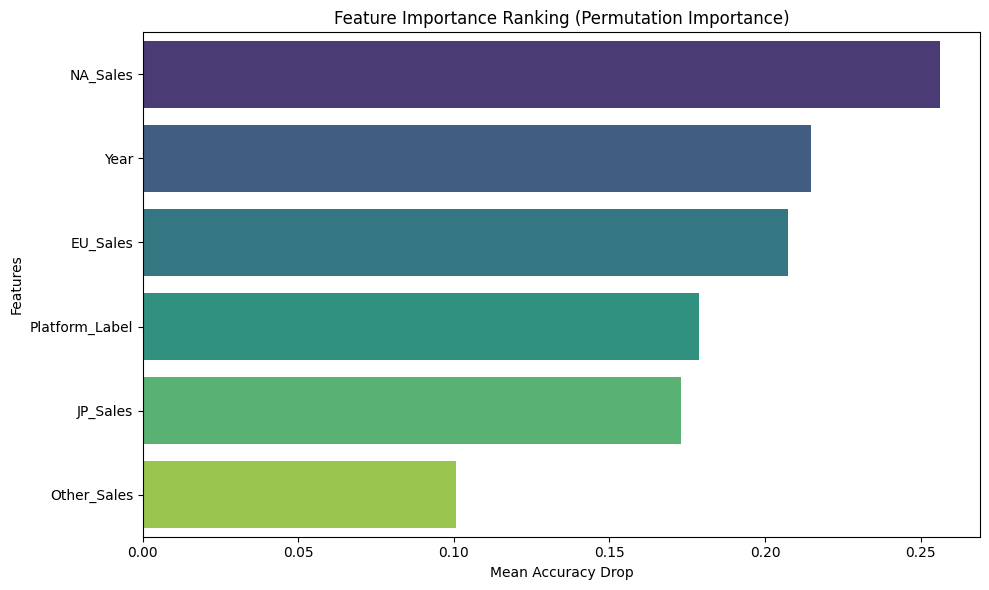

Features ที่เหลือหลังจาก Feature Selection: ['NA_Sales', 'Year', 'EU_Sales', 'Platform_Label', 'JP_Sales', 'Other_Sales']

--- กำลังค้นหา Hyperparameter ที่ดีที่สุด (Grid Search) ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro


สรุปผลการทดลองแบบละเอียด

>>> เทคนิค: KNN
Best Parameters: {'n_neighbors': 7, 'weights': 'uniform'}
Cross Validation Accuracy: 0.2356
Evaluation Accuracy: 0.2335
ความต่าง (Diff): 0.0021

Classification Report for KNN:
              precision    recall  f1-score   support

        2600       0.28      0.53      0.37       650
         3DO       0.26      0.28      0.27       255
         3DS       0.13      0.10      0.11       167
          DC       0.19      0.20      0.19       337
          DS       0.13      0.09      0.11       175
          GB       0.22      0.14      0.17       114
         GBA       0.13      0.09      0.10       245
          GC       0.25      0.18      0.21       294
         GEN       0.15      0.12      0.13       257
          GG       0.13      0.07      0.09       170
         N64       0.30      0.23      0.26       461
         NES       0.14      0.07      0.10       134

    accuracy                           0.23      3259
   macro avg       0.19

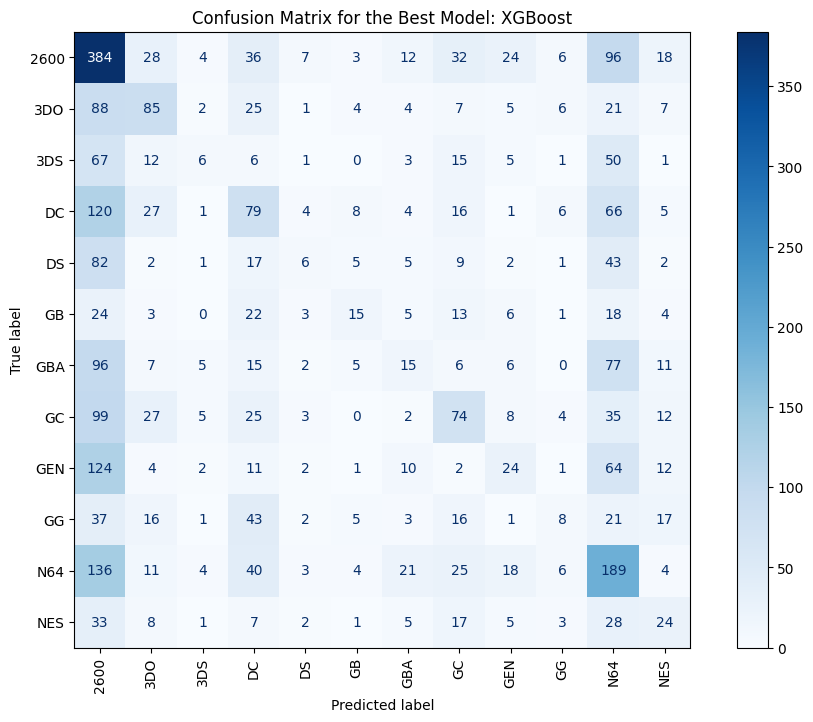


--- สิ้นสุดกระบวนการและแสดงผลครบถ้วนตามเกณฑ์ ---


In [7]:
# ============================================
# 1. Download And Import Library
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# โมเดลและเครื่องมือคัดเลือกลักษณะ
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

# การประเมินประสิทธิภาพ
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ============================================
# 2. Load Dataset & Preprocessing
# ============================================

# อ้างอิงข้อมูลผ่าน Github
url = 'https://raw.githubusercontent.com/chitipatJampa0947/MiniProject1_Cs372/refs/heads/main/video_games_sales.csv'
df = pd.read_csv(url)

# การเตรียมข้อมูล (Preprocessing)
# 1. กำจัด Missing Value โดยละเอียด
df_clean = df.dropna().copy()

# 2. กำจัด Noise (เช่น ข้อมูลปีที่ผิดปกติ)
df_clean = df_clean[df_clean['Year'] <= 2020]

# 3. การทำ Encoding เปลี่ยนข้อมูลหมวดหมู่เป็นตัวเลข
le = LabelEncoder()
df_clean['Genre_Label'] = le.fit_transform(df_clean['Genre'])
df_clean['Platform_Label'] = le.fit_transform(df_clean['Platform'])

# 4. กำหนด Features เบื้องต้น และ Target (ทำนาย Genre)
features_initial = ['Platform_Label', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
X = df_clean[features_initial]
y = df_clean['Genre_Label']

# 5. แบ่งข้อมูล 80/20 (Cross Validation 80% และ Evaluation 20%)
X_train_full, X_eval, y_train_full, y_eval = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ============================================
# 3. Feature Importance & Visualization
# ============================================

print("--- กำลังวิเคราะห์ Feature Importance ---")

# ใช้ XGBoost (Tree-based) หาความสำคัญเบื้องต้น
model_imp = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
model_imp.fit(X_train_full, y_train_full)

# คำนวณ Permutation Importance
perm = permutation_importance(
    model_imp, X_train_full, y_train_full, n_repeats=10, random_state=42
)

# จัดกลุ่มและแสดงผล Ranking
importance_df = pd.DataFrame({
    'feature': features_initial,
    'importance_mean': perm.importances_mean
}).sort_values(by='importance_mean', ascending=False)

print("\n[Ranking คุณลักษณะที่มีความสำคัญ]")
print(importance_df)

# แสดงผล Top 3
top_3 = importance_df['feature'].head(3).tolist()
print(f"\nคุณลักษณะที่มีความสำคัญ Top 3 คือ: {top_3}")

# --- ส่วนการแสดงผลกราฟ (Visualization) ---
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=importance_df, palette='viridis')
plt.title('Feature Importance Ranking (Permutation Importance)')
plt.xlabel('Mean Accuracy Drop')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# ============================================
# 4. Feature Selection
# ============================================
# เลือกเฉพาะ Feature ที่มีผลทางบวก (Feature Selection)
selected_features = importance_df[importance_df['importance_mean'] > 0]['feature'].tolist()
X_train_final = X_train_full[selected_features]
X_eval_final = X_eval[selected_features]

print(f"Features ที่เหลือหลังจาก Feature Selection: {selected_features}")

# ทำ Scaling สำหรับโมเดลที่ไวต่อขนาดข้อมูล (KNN, NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_eval_scaled = scaler.transform(X_eval_final)

# ============================================
# 5. Hyperparameter Tuning (Grid Search)
# ============================================
print("\n--- กำลังค้นหา Hyperparameter ที่ดีที่สุด (Grid Search) ---")

# 5.1 KNN
knn_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}, cv=5)
knn_grid.fit(X_train_scaled, y_train_full)

# 5.2 XGBoost
xgb_grid = GridSearchCV(XGBClassifier(eval_metric='mlogloss'), {'n_estimators': [100, 200], 'max_depth': [3, 5]}, cv=5)
xgb_grid.fit(X_train_final, y_train_full)

# 5.3 Neural Network
mlp_grid = GridSearchCV(MLPClassifier(max_iter=300, random_state=42), {'hidden_layer_sizes': [(50,), (100,)]}, cv=5)
mlp_grid.fit(X_train_scaled, y_train_full)

# ============================================
# 6. ประเมินประสิทธิภาพและวิเคราะห์ Fitting
# ============================================

# สร้างรายชื่อคลาสของ Genre ให้ถูกต้อง(ป้องกัน Error จำนวนคลาสไม่เท่ากัน)
genre_names = le.inverse_transform(np.arange(len(np.unique(y))))

results = {
    'KNN': (knn_grid, X_eval_scaled),
    'XGBoost': (xgb_grid, X_eval_final),
    'Neural Network': (mlp_grid, X_eval_scaled)
}

print("\n" + "="*40)
print("สรุปผลการทดลองแบบละเอียด")
print("="*40)

best_acc = -1
best_model_name = ""

for name, (grid, X_test) in results.items():
    y_pred = grid.predict(X_test)
    acc_cv = grid.best_score_
    acc_eval = accuracy_score(y_eval, y_pred)
    diff = abs(acc_cv - acc_eval)

    if acc_eval > best_acc:
        best_acc = acc_eval
        best_model_name = name

    print(f"\n>>> เทคนิค: {name}")
    print(f"Best Parameters: {grid.best_params_}")
    print(f"Cross Validation Accuracy: {acc_cv:.4f}")
    print(f"Evaluation Accuracy: {acc_eval:.4f}")
    print(f"ความต่าง (Diff): {diff:.4f}")

    # แก้ไขตรงนี้: ใช้ labels เพื่อระบุจำนวนคลาสให้ตรงกับข้อมูลจริง
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_eval, y_pred, labels=np.unique(y), target_names=genre_names))

    # วิเคราะห์ Underfitting / Overfitting
    if diff > 0.10:
        print("สถานะ: อาจเกิดปัญหา Overfitting")
    elif acc_cv < 0.50:
        print("สถานะ: เกิดปัญหา Underfitting (เนื่องจากความแม่นยำต่ำทั้งสองชุด)")
    else:
        print("สถานะ: การเรียนรู้เหมาะสม (Good Fitting)")
    print("-" * 30)

# ============================================
# 7. Visualization: Confusion Matrix (เลือกโมเดลที่ดีที่สุดอัตโนมัติ)
# ============================================
print(f"\n*** ระบบเลือกโมเดล {best_model_name} มาแสดงผล เนื่องจากมีค่า Accuracy สูงที่สุด ({best_acc:.4f}) ***")

grid, X_test = results[best_model_name]
y_pred = grid.predict(X_test)

# สร้างรายชื่อคลาสที่ถูกต้องสำหรับกราฟ (12 คลาส)
current_genre_names = le.inverse_transform(np.arange(len(np.unique(y))))

cm = confusion_matrix(y_eval, y_pred)
fig, ax = plt.subplots(figsize=(12, 8)) # แก้ไขการสร้าง figure
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_genre_names)
disp.plot(cmap='Blues', xticks_rotation='vertical', ax=ax) # ระบุ ax=ax
plt.title(f'Confusion Matrix for the Best Model: {best_model_name}')
plt.show()

print("\n--- สิ้นสุดกระบวนการและแสดงผลครบถ้วนตามเกณฑ์ ---")